In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy import stats

# Distribution plot

Dataset shape: (15336, 9)
Columns: ['CISI', 'Subscore_energy', 'Subscore_transportation', 'Subscore_water', 'Subscore_waste', 'Subscore_telecommunication', 'Subscore_healthcare', 'Subscore_education', 'geometry']

CISI STATISTICS
Count: 15,336
Mean: 0.0395
Median: 0.0250
Std: 0.0500
Min: 0.0000
Max: 1.0000

Percentiles:
  50th: 0.0250
  75th: 0.0540
  90th: 0.0923
  95th: 0.1260
  99th: 0.2305
  99.9th: 0.4633


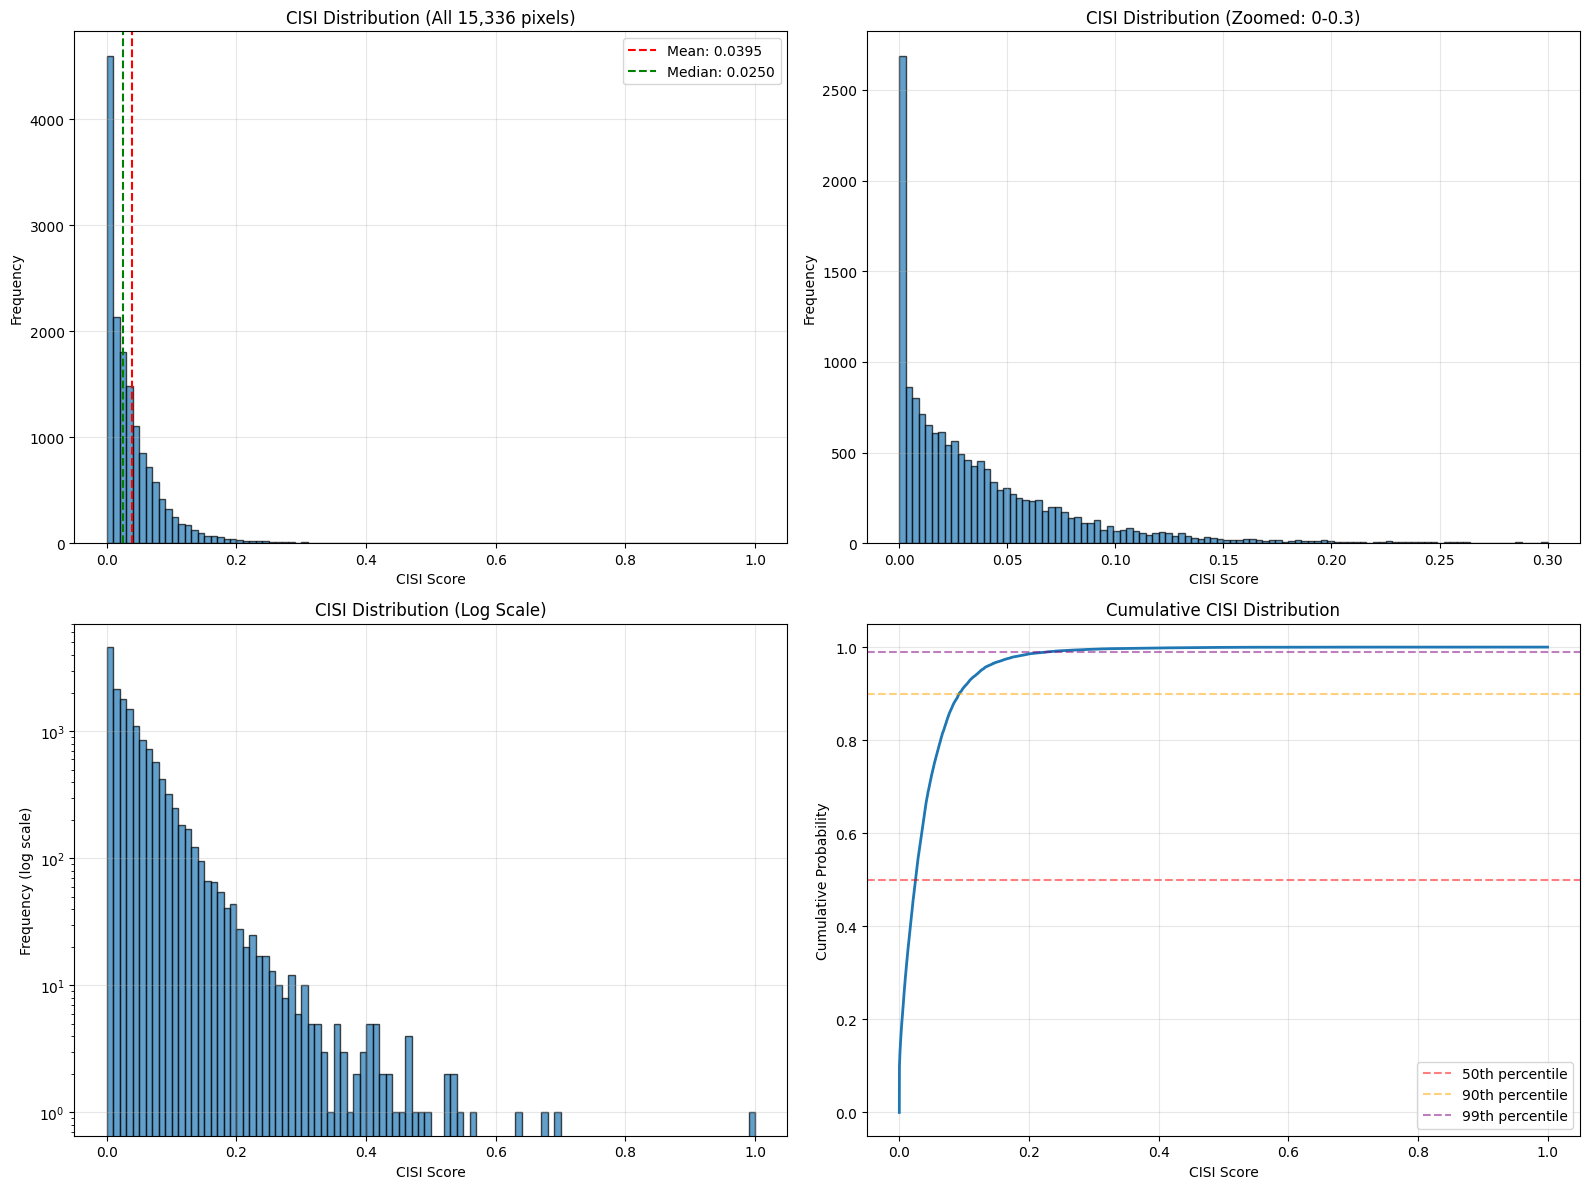


TOP 20 HIGHEST CISI SCORES
          CISI
5720  1.000000
8098  0.690217
802   0.677357
7494  0.638738
6540  0.561691
2617  0.543978
1315  0.533775
3673  0.533404
4844  0.527658
3612  0.524620
7955  0.491903
5766  0.484237
7441  0.476809
3097  0.465442
6710  0.464768
7908  0.463649
1584  0.462514
5142  0.457682
5302  0.441858
4433  0.438027


In [2]:
# Load the feather file
feather_path = r'READY_data\labels\CISI_exposure_Europe_025deg.feather'
df = pd.read_feather(feather_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Basic CISI statistics
print(f"\n{'='*80}")
print("CISI STATISTICS")
print(f"{'='*80}")
print(f"Count: {len(df):,}")
print(f"Mean: {df['CISI'].mean():.4f}")
print(f"Median: {df['CISI'].median():.4f}")
print(f"Std: {df['CISI'].std():.4f}")
print(f"Min: {df['CISI'].min():.4f}")
print(f"Max: {df['CISI'].max():.4f}")

# Percentiles
percentiles = [50, 75, 90, 95, 99, 99.9]
print(f"\nPercentiles:")
for p in percentiles:
    val = df['CISI'].quantile(p/100)
    print(f"  {p}th: {val:.4f}")

# Create histogram
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Full distribution
ax1 = axes[0, 0]
ax1.hist(df['CISI'], bins=100, edgecolor='black', alpha=0.7)
ax1.set_xlabel('CISI Score')
ax1.set_ylabel('Frequency')
ax1.set_title(f'CISI Distribution (All {len(df):,} pixels)')
ax1.axvline(df['CISI'].mean(), color='red', linestyle='--', label=f'Mean: {df["CISI"].mean():.4f}')
ax1.axvline(df['CISI'].median(), color='green', linestyle='--', label=f'Median: {df["CISI"].median():.4f}')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Zoomed to 0-0.3 (where most data is)
ax2 = axes[0, 1]
ax2.hist(df['CISI'], bins=100, range=(0, 0.3), edgecolor='black', alpha=0.7)
ax2.set_xlabel('CISI Score')
ax2.set_ylabel('Frequency')
ax2.set_title('CISI Distribution (Zoomed: 0-0.3)')
ax2.grid(alpha=0.3)

# 3. Log scale
ax3 = axes[1, 0]
ax3.hist(df['CISI'], bins=100, edgecolor='black', alpha=0.7)
ax3.set_xlabel('CISI Score')
ax3.set_ylabel('Frequency (log scale)')
ax3.set_title('CISI Distribution (Log Scale)')
ax3.set_yscale('log')
ax3.grid(alpha=0.3)

# 4. Cumulative distribution
ax4 = axes[1, 1]
sorted_cisi = np.sort(df['CISI'])
cumulative = np.arange(1, len(sorted_cisi) + 1) / len(sorted_cisi)
ax4.plot(sorted_cisi, cumulative, linewidth=2)
ax4.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50th percentile')
ax4.axhline(0.9, color='orange', linestyle='--', alpha=0.5, label='90th percentile')
ax4.axhline(0.99, color='purple', linestyle='--', alpha=0.5, label='99th percentile')
ax4.set_xlabel('CISI Score')
ax4.set_ylabel('Cumulative Probability')
ax4.set_title('Cumulative CISI Distribution')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cisi_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Show top values
print(f"\n{'='*80}")
print("TOP 20 HIGHEST CISI SCORES")
print(f"{'='*80}")
top20 = df.nlargest(20, 'CISI')[['CISI']]
print(top20.to_string(index=True))

# Power Law

Total pixels: 15,336
Non-zero CISI: 14,164 (92.4%)
Zero CISI: 1,172


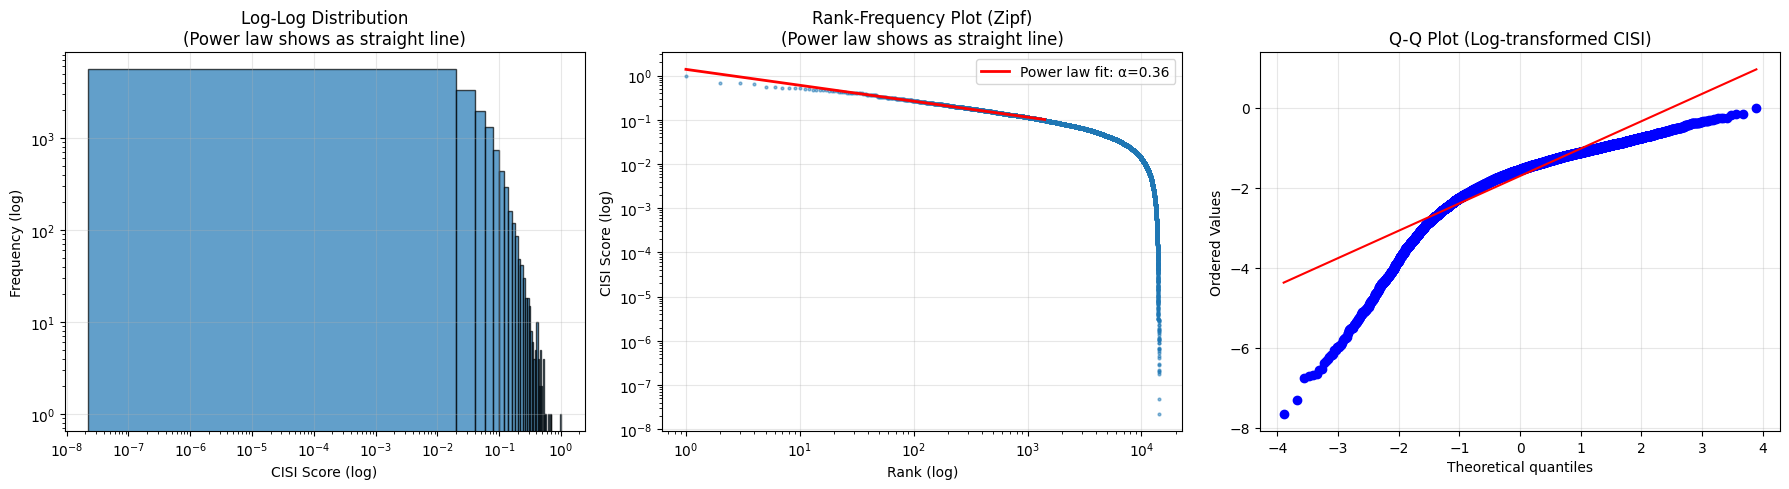


POWER LAW ANALYSIS
Power law exponent (α): 0.360
(α ≈ 2-3 indicates typical city size distribution)

Interpretation:
  → Distribution more uniform across cities


In [3]:
# Filter out zeros for power law analysis
cisi_nonzero = df[df['CISI'] > 0]['CISI']

print(f"Total pixels: {len(df):,}")
print(f"Non-zero CISI: {len(cisi_nonzero):,} ({len(cisi_nonzero)/len(df)*100:.1f}%)")
print(f"Zero CISI: {(df['CISI'] == 0).sum():,}")

# Log-log plot to check for power law
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Log-log histogram
ax1 = axes[0]
counts, bins, _ = ax1.hist(cisi_nonzero, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('CISI Score (log)')
ax1.set_ylabel('Frequency (log)')
ax1.set_title('Log-Log Distribution\n(Power law shows as straight line)')
ax1.grid(alpha=0.3)

# 2. Rank-frequency plot (Zipf plot)
ax2 = axes[1]
sorted_cisi = np.sort(cisi_nonzero)[::-1]  # Descending
ranks = np.arange(1, len(sorted_cisi) + 1)
ax2.loglog(ranks, sorted_cisi, 'o', markersize=2, alpha=0.5)
ax2.set_xlabel('Rank (log)')
ax2.set_ylabel('CISI Score (log)')
ax2.set_title('Rank-Frequency Plot (Zipf)\n(Power law shows as straight line)')
ax2.grid(alpha=0.3)

# Fit power law to tail (top 10%)
tail_size = int(len(sorted_cisi) * 0.1)
tail_ranks = ranks[:tail_size]
tail_cisi = sorted_cisi[:tail_size]

# Log-log linear fit
log_ranks = np.log10(tail_ranks)
log_cisi = np.log10(tail_cisi)
slope, intercept = np.polyfit(log_ranks, log_cisi, 1)
ax2.loglog(tail_ranks, 10**(intercept + slope * np.log10(tail_ranks)), 
           'r-', linewidth=2, label=f'Power law fit: α={-slope:.2f}')
ax2.legend()

# 3. Q-Q plot against power law
ax3 = axes[2]
stats.probplot(np.log10(cisi_nonzero), dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Log-transformed CISI)')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cisi_power_law_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("POWER LAW ANALYSIS")
print(f"{'='*80}")
print(f"Power law exponent (α): {-slope:.3f}")
print(f"(α ≈ 2-3 indicates typical city size distribution)")
print(f"\nInterpretation:")
if -slope > 2.5:
    print("  → Distribution more concentrated in few large cities")
elif -slope < 1.5:
    print("  → Distribution more uniform across cities")
else:
    print("  → Typical urban hierarchy (Zipf's law)")

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.optimize import curve_fit

# Load data
df = pd.read_feather(r'READY_data\labels\CISI_exposure_Europe_025deg.feather')
cisi_nonzero = df[df['CISI'] > 0]['CISI'].values

print(f"{'='*80}")
print("STATISTICAL DISTRIBUTION ANALYSIS")
print(f"{'='*80}")

# ============================================================================
# 1. POWER LAW FIT
# ============================================================================
print("\n1. POWER LAW ANALYSIS")
print("-" * 80)

# Use only tail (top 10% for cleaner fit)
sorted_cisi = np.sort(cisi_nonzero)[::-1]
tail_size = int(len(sorted_cisi) * 0.1)
tail_cisi = sorted_cisi[:tail_size]

# Fit: P(X > x) ~ x^(-α)
# Use complementary CDF
ccdf = np.arange(1, len(tail_cisi) + 1) / len(cisi_nonzero)

# Log-log linear regression
log_x = np.log10(tail_cisi)
log_y = np.log10(ccdf)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)
alpha = -slope

print(f"Power law exponent (α): {alpha:.3f}")
print(f"R² of log-log fit: {r_value**2:.4f}")
print(f"p-value: {p_value:.4e}")

# Kolmogorov-Smirnov test for power law
from scipy.stats import kstest
def power_law_cdf(x, alpha, xmin):
    return 1 - (x / xmin) ** (1 - alpha)

xmin = tail_cisi.min()
ks_stat, ks_pval = kstest(tail_cisi, lambda x: power_law_cdf(x, alpha, xmin))
print(f"KS test statistic: {ks_stat:.4f}")
print(f"KS p-value: {ks_pval:.4f}")
print(f"  → {'REJECT' if ks_pval < 0.05 else 'FAIL TO REJECT'} power law (α=0.05)")

# ============================================================================
# 2. LOG-NORMAL FIT
# ============================================================================
print("\n2. LOG-NORMAL DISTRIBUTION")
print("-" * 80)

log_cisi = np.log(cisi_nonzero)
mu, sigma = log_cisi.mean(), log_cisi.std()

print(f"Log-normal parameters:")
print(f"  μ (log mean): {mu:.4f}")
print(f"  σ (log std): {sigma:.4f}")
print(f"  Median (e^μ): {np.exp(mu):.4f}")
print(f"  Mode (e^(μ-σ²)): {np.exp(mu - sigma**2):.4f}")

# Anderson-Darling test
ad_stat, ad_crit, ad_sig = stats.anderson(log_cisi, dist='norm')
print(f"\nAnderson-Darling test:")
print(f"  Statistic: {ad_stat:.4f}")
for i, (crit, sig) in enumerate(zip(ad_crit, ad_sig)):
    result = "REJECT" if ad_stat > crit else "FAIL TO REJECT"
    print(f"  {sig}% significance: {crit:.3f} → {result} log-normal")

# ============================================================================
# 3. EXPONENTIAL FIT
# ============================================================================
print("\n3. EXPONENTIAL DISTRIBUTION")
print("-" * 80)

# MLE for exponential: λ = 1/mean
lambda_exp = 1 / cisi_nonzero.mean()
print(f"Rate parameter (λ): {lambda_exp:.4f}")
print(f"Mean: {1/lambda_exp:.4f}")

# KS test for exponential
ks_exp, pval_exp = stats.kstest(cisi_nonzero, 'expon', args=(0, 1/lambda_exp))
print(f"KS test statistic: {ks_exp:.4f}")
print(f"KS p-value: {pval_exp:.4f}")
print(f"  → {'REJECT' if pval_exp < 0.05 else 'FAIL TO REJECT'} exponential")

# ============================================================================
# 4. PARETO FIT (alternative power law)
# ============================================================================
print("\n4. PARETO DISTRIBUTION")
print("-" * 80)

# Fit Pareto: P(X > x) = (xmin/x)^α
xmin_pareto = cisi_nonzero.min()
alpha_pareto = 1 + len(cisi_nonzero) / np.sum(np.log(cisi_nonzero / xmin_pareto))

print(f"Shape parameter (α): {alpha_pareto:.4f}")
print(f"Scale (xmin): {xmin_pareto:.4f}")
print(f"Mean: {alpha_pareto * xmin_pareto / (alpha_pareto - 1) if alpha_pareto > 1 else 'undefined':.4f}")

# ============================================================================
# 5. WEIBULL FIT
# ============================================================================
print("\n5. WEIBULL DISTRIBUTION")
print("-" * 80)

shape_w, loc_w, scale_w = stats.weibull_min.fit(cisi_nonzero, floc=0)
print(f"Shape (k): {shape_w:.4f}")
print(f"Scale (λ): {scale_w:.4f}")

ks_weib, pval_weib = stats.kstest(cisi_nonzero, 'weibull_min', args=(shape_w, loc_w, scale_w))
print(f"KS test statistic: {ks_weib:.4f}")
print(f"KS p-value: {pval_weib:.4f}")

# ============================================================================
# 6. COMPARE ALL DISTRIBUTIONS (AIC/BIC)
# ============================================================================
print("\n6. MODEL COMPARISON (AIC/BIC)")
print("-" * 80)

def compute_aic_bic(log_likelihood, n_params, n_data):
    aic = 2 * n_params - 2 * log_likelihood
    bic = n_params * np.log(n_data) - 2 * log_likelihood
    return aic, bic

n = len(cisi_nonzero)

# Log-likelihood for each distribution
ll_lognorm = np.sum(stats.lognorm.logpdf(cisi_nonzero, sigma, scale=np.exp(mu)))
ll_exp = np.sum(stats.expon.logpdf(cisi_nonzero, scale=1/lambda_exp))
ll_weib = np.sum(stats.weibull_min.logpdf(cisi_nonzero, shape_w, loc_w, scale_w))

aic_ln, bic_ln = compute_aic_bic(ll_lognorm, 2, n)
aic_exp, bic_exp = compute_aic_bic(ll_exp, 1, n)
aic_weib, bic_weib = compute_aic_bic(ll_weib, 2, n)

print(f"{'Distribution':<20} {'AIC':>12} {'BIC':>12} {'Log-Likelihood':>15}")
print("-" * 60)
print(f"{'Log-Normal':<20} {aic_ln:>12.2f} {bic_ln:>12.2f} {ll_lognorm:>15.2f}")
print(f"{'Exponential':<20} {aic_exp:>12.2f} {bic_exp:>12.2f} {ll_exp:>15.2f}")
print(f"{'Weibull':<20} {aic_weib:>12.2f} {bic_weib:>12.2f} {ll_weib:>15.2f}")
print("\n(Lower AIC/BIC = better fit)")

best_aic = min(aic_ln, aic_exp, aic_weib)
if best_aic == aic_ln:
    print("\n→ BEST FIT: Log-Normal distribution")
elif best_aic == aic_exp:
    print("\n→ BEST FIT: Exponential distribution")
else:
    print("\n→ BEST FIT: Weibull distribution")

# ============================================================================
# 7. HEAVY-TAIL TEST
# ============================================================================
print("\n7. HEAVY-TAIL CHARACTERISTICS")
print("-" * 80)

# Kurtosis (excess kurtosis > 0 indicates heavy tails)
kurtosis = stats.kurtosis(cisi_nonzero)
print(f"Excess kurtosis: {kurtosis:.4f}")
print(f"  → {'Heavy-tailed' if kurtosis > 3 else 'Light-tailed' if kurtosis < 0 else 'Moderate'}")

# Tail index (Hill estimator for upper tail)
k_tail = 100  # Top 100 observations
sorted_desc = np.sort(cisi_nonzero)[::-1]
hill_estimator = np.mean(np.log(sorted_desc[:k_tail] / sorted_desc[k_tail]))
tail_index = 1 / hill_estimator

print(f"Hill estimator (α): {tail_index:.4f}")
print(f"  → α > 2: Heavy tail (infinite variance)")

STATISTICAL DISTRIBUTION ANALYSIS

1. POWER LAW ANALYSIS
--------------------------------------------------------------------------------
Power law exponent (α): 2.751
R² of log-log fit: 0.9908
p-value: 0.0000e+00
KS test statistic: 0.1222
KS p-value: 0.0000
  → REJECT power law (α=0.05)

2. LOG-NORMAL DISTRIBUTION
--------------------------------------------------------------------------------
Log-normal parameters:
  μ (log mean): -3.9359
  σ (log std): 1.7026
  Median (e^μ): 0.0195
  Mode (e^(μ-σ²)): 0.0011

Anderson-Darling test:
  Statistic: 452.6076
  15.0% significance: 0.576 → REJECT log-normal
  10.0% significance: 0.656 → REJECT log-normal
  5.0% significance: 0.787 → REJECT log-normal
  2.5% significance: 0.918 → REJECT log-normal
  1.0% significance: 1.092 → REJECT log-normal

3. EXPONENTIAL DISTRIBUTION
--------------------------------------------------------------------------------
Rate parameter (λ): 23.4023
Mean: 0.0427
KS test statistic: 0.0409
KS p-value: 0.0000
  → R

# Cities

In [5]:
import pandas as pd
import geopandas as gpd
from shapely import wkb

# Load feather
df = pd.read_feather(r'READY_data\labels\CISI_exposure_Europe_025deg.feather')

# Convert geometry from WKB to actual geometries
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkb(df['geometry']))
gdf = gdf.set_crs('EPSG:4326')

# Get top 20
top20 = gdf.nlargest(20, 'CISI').copy()

# Extract centroids (lat/lon)
top20['longitude'] = top20.geometry.centroid.x
top20['latitude'] = top20.geometry.centroid.y

# Display
print(f"{'='*80}")
print("TOP 20 HIGHEST CISI LOCATIONS")
print(f"{'='*80}")
print(f"{'Rank':<6} {'CISI':<8} {'Latitude':<12} {'Longitude':<12}")
print("-" * 80)

for rank, (idx, row) in enumerate(top20.iterrows(), 1):
    print(f"{rank:<6} {row['CISI']:<8.4f} {row['latitude']:<12.4f} {row['longitude']:<12.4f}")

# Use reverse geocoding to get city names (requires geopy)
try:
    from geopy.geocoders import Nominatim
    from time import sleep
    
    print(f"\n{'='*80}")
    print("IDENTIFYING CITIES (this may take a minute...)")
    print(f"{'='*80}")
    
    geolocator = Nominatim(user_agent="cisi_analysis")
    
    cities = []
    for rank, (idx, row) in enumerate(top20.iterrows(), 1):
        try:
            location = geolocator.reverse(f"{row['latitude']}, {row['longitude']}", language='en')
            
            # Extract city name from address
            address = location.raw.get('address', {})
            city = (address.get('city') or 
                   address.get('town') or 
                   address.get('village') or 
                   address.get('municipality') or
                   address.get('county') or
                   'Unknown')
            country = address.get('country', 'Unknown')
            
            cities.append({
                'Rank': rank,
                'CISI': row['CISI'],
                'City': city,
                'Country': country,
                'Lat': row['latitude'],
                'Lon': row['longitude']
            })
            
            print(f"{rank:<4} {row['CISI']:.4f}  {city:<25} {country}")
            sleep(1.1)  # Rate limit: max 1 request/sec
            
        except Exception as e:
            print(f"{rank:<4} {row['CISI']:.4f}  [Geocoding failed]")
            cities.append({
                'Rank': rank,
                'CISI': row['CISI'],
                'City': 'Error',
                'Country': 'Error',
                'Lat': row['latitude'],
                'Lon': row['longitude']
            })
    
    # Save to CSV
    cities_df = pd.DataFrame(cities)
    cities_df.to_csv('top20_cisi_cities.csv', index=False)
    print(f"\nSaved to: top20_cisi_cities.csv")
    
except ImportError:
    print("\nInstall geopy for automatic city identification:")
    print("  pip install geopy")
    print("\nOr manually check coordinates at: https://www.google.com/maps")

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_26992\119321674.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top20['longitude'] = top20.geometry.centroid.x
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_26992\119321674.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top20['latitude'] = top20.geometry.centroid.y


TOP 20 HIGHEST CISI LOCATIONS
Rank   CISI     Latitude     Longitude   
--------------------------------------------------------------------------------
1      1.0000   48.7833      2.3750      
2      0.6902   52.5333      13.3750     
3      0.6774   38.7833      -9.1250     
4      0.6387   51.5333      -0.1250     
5      0.5617   50.0333      14.3750     
6      0.5440   43.5333      1.3750      
7      0.5338   40.5333      -3.6250     
8      0.5334   45.7833      4.8750      
9      0.5277   47.5333      19.1250     
10     0.5246   45.5333      9.1250      
11     0.4919   52.2833      20.8750     
12     0.4842   48.7833      2.1250      
13     0.4768   51.5333      0.1250      
14     0.4654   44.5333      26.1250     
15     0.4648   50.2833      19.1250     
16     0.4636   52.2833      21.1250     
17     0.4625   41.2833      -8.6250     
18     0.4577   48.0333      37.8750     
19     0.4419   48.2833      16.3750     
20     0.4380   47.0333      28.8750     

IDENTI